In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [10]:
import numpy as np

In [27]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)
images, _ = next(iter(trainloader))

print("Original batch shape:", images.shape)

images_flat = images.view(images.size(0), -1)

print("Flattened input shape:", images_flat.shape)

Original batch shape: torch.Size([128, 3, 32, 32])
Flattened input shape: torch.Size([128, 3072])


In [12]:
class SparseAutoencoder(nn.Module):

    def __init__(self):

        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),

            nn.Linear(1024, 256),
            nn.ReLU(),

            nn.Linear(256, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),

            nn.Linear(256, 1024),
            nn.ReLU(),

            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

In [13]:
def sparsity_penalty(rho, rho_hat):

    rho_hat = torch.mean(torch.sigmoid(rho_hat), dim=0)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)

In [31]:
model = SparseAutoencoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

rho = 0.05
beta = 1e-4
epochs = 50

In [32]:
encoded, decoded = model(images_flat)

print("Encoded feature shape:", encoded.shape)
print("Decoded output shape:", decoded.shape)

Encoded feature shape: torch.Size([128, 64])
Decoded output shape: torch.Size([128, 3072])


In [33]:
train_losses = []

for epoch in range(epochs):

    total_loss = 0

    for images, _ in trainloader:

        images = images.view(images.size(0), -1)

        encoded, outputs = model(images)

        recon_loss = criterion(outputs, images)

        sparse_loss = sparsity_penalty(rho, encoded)

        loss = recon_loss + beta * sparse_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(trainloader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}")

Epoch 1/50 Loss: 0.2093
Epoch 2/50 Loss: 0.1863
Epoch 3/50 Loss: 0.1809
Epoch 4/50 Loss: 0.1775
Epoch 5/50 Loss: 0.1757
Epoch 6/50 Loss: 0.1743
Epoch 7/50 Loss: 0.1731
Epoch 8/50 Loss: 0.1724
Epoch 9/50 Loss: 0.1719
Epoch 10/50 Loss: 0.1715
Epoch 11/50 Loss: 0.1711
Epoch 12/50 Loss: 0.1708
Epoch 13/50 Loss: 0.1705
Epoch 14/50 Loss: 0.1703
Epoch 15/50 Loss: 0.1700
Epoch 16/50 Loss: 0.1698
Epoch 17/50 Loss: 0.1697
Epoch 18/50 Loss: 0.1695
Epoch 19/50 Loss: 0.1694
Epoch 20/50 Loss: 0.1692
Epoch 21/50 Loss: 0.1691
Epoch 22/50 Loss: 0.1690
Epoch 23/50 Loss: 0.1688
Epoch 24/50 Loss: 0.1687
Epoch 25/50 Loss: 0.1686
Epoch 26/50 Loss: 0.1685
Epoch 27/50 Loss: 0.1685
Epoch 28/50 Loss: 0.1684
Epoch 29/50 Loss: 0.1682
Epoch 30/50 Loss: 0.1682
Epoch 31/50 Loss: 0.1681
Epoch 32/50 Loss: 0.1680
Epoch 33/50 Loss: 0.1680
Epoch 34/50 Loss: 0.1679
Epoch 35/50 Loss: 0.1678
Epoch 36/50 Loss: 0.1678
Epoch 37/50 Loss: 0.1677
Epoch 38/50 Loss: 0.1676
Epoch 39/50 Loss: 0.1676
Epoch 40/50 Loss: 0.1675
Epoch 41/

In [35]:
input_dim = 3072
latent_dim = 64

compression_ratio = input_dim / latent_dim

print("Original dimension:", input_dim)
print("Latent dimension:", latent_dim)
print("Compression ratio:", compression_ratio)

Original dimension: 3072
Latent dimension: 64
Compression ratio: 48.0


In [36]:
print("\nEncoder Layer Compression")

x = images_flat

for layer in model.encoder:
    x = layer(x)
    print(layer, "→", x.shape)


Encoder Layer Compression
Linear(in_features=3072, out_features=1024, bias=True) → torch.Size([128, 1024])
ReLU() → torch.Size([128, 1024])
Linear(in_features=1024, out_features=256, bias=True) → torch.Size([128, 256])
ReLU() → torch.Size([128, 256])
Linear(in_features=256, out_features=64, bias=True) → torch.Size([128, 64])
ReLU() → torch.Size([128, 64])


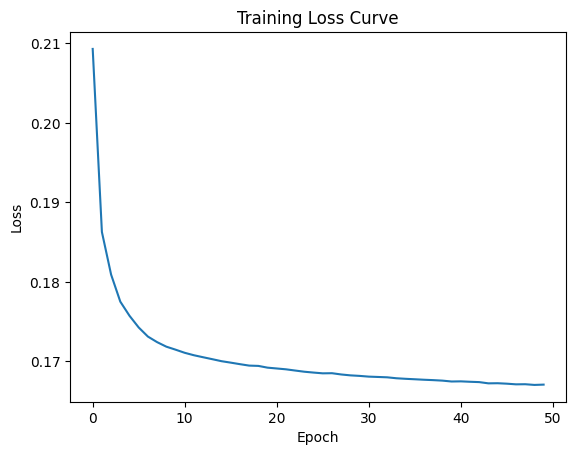

In [37]:
plt.plot(train_losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [38]:
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in testloader:

        images = images.view(images.size(0), -1)

        _, outputs = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss / len(testloader))

Test Reconstruction Loss: 0.16482577576667448


In [39]:
dataiter = iter(testloader)

images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1)

_, outputs = model(images_flat)

outputs = outputs.view(-1,3,32,32)

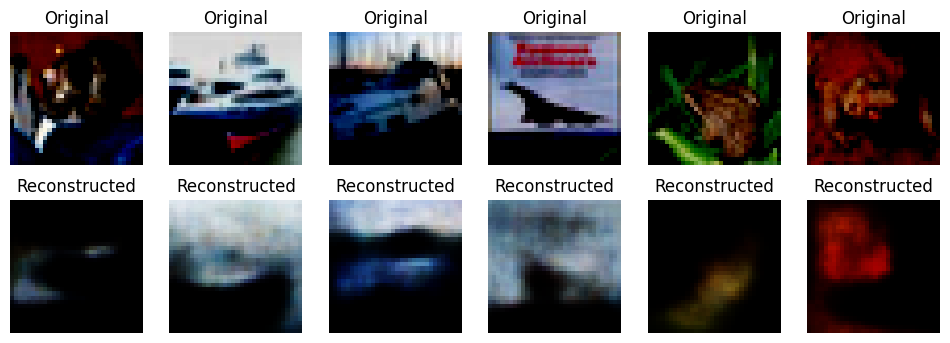

In [41]:
fig, axes = plt.subplots(2,6, figsize=(12,4))

for i in range(6):

    axes[0,i].imshow(images[i].permute(1,2,0).detach().numpy())
    axes[0,i].set_title("Original")

    axes[1,i].imshow(outputs[i].permute(1,2,0).detach().numpy())
    axes[1,i].set_title("Reconstructed")

    axes[0,i].axis("off")
    axes[1,i].axis("off")

plt.show()

In [42]:
encoded_features = []

with torch.no_grad():

    for images, _ in testloader:

        images = images.view(images.size(0), -1)

        encoded, _ = model(images)

        encoded_features.append(encoded)

encoded_features = torch.cat(encoded_features)

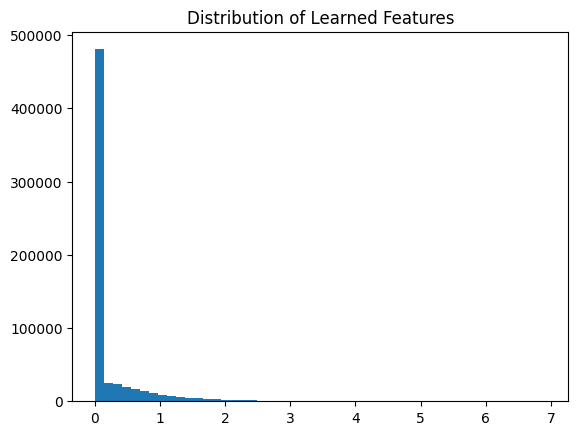

In [43]:
plt.hist(encoded_features.numpy().flatten(), bins=50)

plt.title("Distribution of Learned Features")

plt.show()

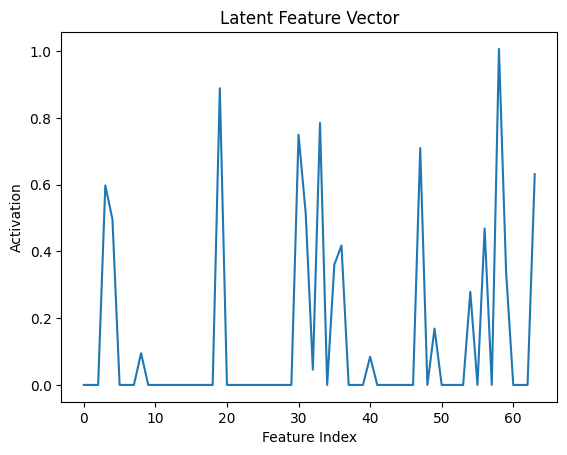

In [44]:
feature_vector = encoded_features[0].numpy()

plt.plot(feature_vector)

plt.title("Latent Feature Vector")

plt.xlabel("Feature Index")

plt.ylabel("Activation")

plt.show()